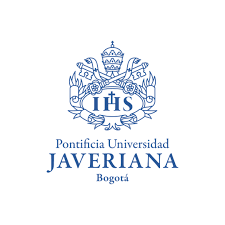
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### **Bonus: Implementación de red neuronal**

Grupo Sigma


Fecha actual: 24/05/2026

In [1]:
### Importación de bibliotecas basicas 
import os                       # -> Para gestion de archivos y procesos
import sys                      # -> Para manejo de recursos del sistema
import pandas as pd             # -> Para graficar y objetos dataframe
import numpy as np              # -> Para algebra matricial
import matplotlib.pyplot as plt # -> Para formatos de graficas
import seaborn as sns           # -> Para estadistica y graficar
### Importacion de bibliotecas especializadas
import findspark                                # -> Para manejo del entorno de PySpark
findspark.init('/Almacen/Spark')                # -> Se inicia el entorno para PySpark
from pyspark import SparkConf, SparkContext     # -> Para contexto y configuración de PySpark
from pyspark.sql import SparkSession            # -> Para manejo de Sesion en entorno de consultas SQL
from pyspark.sql.functions import *             # -> Para funciones de manipulacion de columnas
from pyspark.sql.types import IntegerType, StringType, DoubleType # -> Para definir tipos de datos


In [2]:
configura = SparkConf()
configura.set('spark.scheduler.mode', 'FAIR')
configura.set('spark.scheduler.allocation','/Almacen/Spark/conf/fairscheduler.xml')
configura.setMaster('spark://10.43.97.166:7077')
configura.setAppName('SigmaSPARK')

sparkSigma = SparkSession.builder.config(conf=configura).getOrCreate()
sparkSigma

## Lectura de los datos

In [3]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
datosIcfes = sparkSigma.read.format("csv").option("header","true").option("inferSchema", "true").option("encoding", "UTF-8").load("daticos11.csv")
datosIcfes.show(2)


+-------+------------------+----------------+-------------------+-------------+---------------+-----------------+-----------------------------+------------------+------------------------+------------------------+-----------------+--------------------+-----------+------------+--------------------+---------------+---------------------------+----------------+-------------------+---------------------------+---------------------------+---------------------+---------------------+-----------------------+-----------------+------------------------+---------------+--------------------+-----------+-----------------------+-----------------+-----------------+----------------+---------------------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-------------+-----------+----------------+------------------------+----------------+--------------------+-----------+
|PERIODO|

## 	***`Diccionario de datos`***
> Dataset: [datos.gov.co/kgxf-xxbe](https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/kgxf-xxbe/about_data)
> Total columnas: **51**

---

## 🗓️ Identificación general del registro (3 columnas)

| Columna | Descripción |
|---|---|
| `PERIODO` | Año y semestre en que se aplicó la prueba (ej. 20231 = primer semestre de 2023) |
| `ESTU_TIPODOCUMENTO` | Tipo de documento de identidad del estudiante (CC, TI, PEP, etc.) |
| `ESTU_CONSECUTIVO` | Número consecutivo único que identifica al estudiante dentro del periodo |

---

## 🏫 Información del colegio (17 columnas)

| Columna | Descripción |
|---|---|
| `COLE_NOMBRE_ESTABLECIMIENTO` | Nombre oficial del establecimiento educativo |
| `COLE_NOMBRE_SEDE` | Nombre de la sede específica del colegio |
| `COLE_SEDE_PRINCIPAL` | Indica si la sede es la sede principal (S/N) |
| `COLE_COD_DANE_ESTABLECIMIENTO` | Código DANE del establecimiento educativo |
| `COLE_COD_DANE_SEDE` | Código DANE de la sede específica |
| `COLE_CODIGO_ICFES` | Código asignado por el ICFES al colegio |
| `COLE_NATURALEZA` | Naturaleza del colegio: oficial o no oficial (privado) |
| `COLE_CALENDARIO` | Calendario académico del colegio (A o B) |
| `COLE_CARACTER` | Carácter académico del colegio (académico, técnico, etc.) |
| `COLE_GENERO` | Género de la población atendida por el colegio (mixto, femenino, masculino) |
| `COLE_JORNADA` | Jornada escolar del colegio (mañana, tarde, noche, completa, etc.) |
| `COLE_BILINGUE` | Indica si el colegio es bilingüe (S/N) |
| `COLE_AREA_UBICACION` | Área de ubicación del colegio: urbana o rural |
| `COLE_DEPTO_UBICACION` | Nombre del departamento donde está ubicado el colegio |
| `COLE_COD_DEPTO_UBICACION` | Código del departamento donde está ubicado el colegio |
| `COLE_MCPIO_UBICACION` | Nombre del municipio donde está ubicado el colegio |
| `COLE_COD_MCPIO_UBICACION` | Código del municipio donde está ubicado el colegio |

---

## 👤 Información del estudiante (6 columnas)

| Columna | Descripción |
|---|---|
| `ESTU_ESTUDIANTE` | Identificador anonimizado del estudiante |
| `ESTU_GENERO` | Género del estudiante (F/M) |
| `ESTU_FECHANACIMIENTO` | Fecha de nacimiento del estudiante |
| `ESTU_NACIONALIDAD` | Nacionalidad del estudiante |
| `ESTU_PRIVADO_LIBERTAD` | Indica si el estudiante está privado de la libertad (S/N) |
| `ESTU_ESTADOINVESTIGACION` | Estado del registro en procesos de investigación o auditoría del ICFES |

---

## 📍 Ubicación y presentación del estudiante (9 columnas)

| Columna | Descripción |
|---|---|
| `ESTU_DEPTO_PRESENTACION` | Nombre del departamento donde el estudiante presentó la prueba |
| `ESTU_COD_DEPTO_PRESENTACION` | Código del departamento donde el estudiante presentó la prueba |
| `ESTU_MCPIO_PRESENTACION` | Nombre del municipio donde el estudiante presentó la prueba |
| `ESTU_COD_MCPIO_PRESENTACION` | Código del municipio donde el estudiante presentó la prueba |
| `ESTU_DEPTO_RESIDE` | Nombre del departamento donde reside el estudiante |
| `ESTU_COD_RESIDE_DEPTO` | Código del departamento de residencia del estudiante |
| `ESTU_MCPIO_RESIDE` | Nombre del municipio donde reside el estudiante |
| `ESTU_COD_RESIDE_MCPIO` | Código del municipio de residencia del estudiante |
| `ESTU_PAIS_RESIDE` | País de residencia del estudiante |

---

## 🏠 Contexto familiar y socioeconómico (9 columnas)

| Columna | Descripción |
|---|---|
| `FAMI_ESTRATOVIVIENDA` | Estrato socioeconómico de la vivienda del estudiante (1 al 6) |
| `FAMI_PERSONASHOGAR` | Número de personas que viven en el hogar del estudiante |
| `FAMI_CUARTOSHOGAR` | Número de cuartos disponibles en el hogar del estudiante |
| `FAMI_EDUCACIONMADRE` | Nivel educativo más alto alcanzado por la madre del estudiante |
| `FAMI_EDUCACIONPADRE` | Nivel educativo más alto alcanzado por el padre del estudiante |
| `FAMI_TIENEAUTOMOVIL` | Indica si el hogar del estudiante tiene automóvil (S/N) |
| `FAMI_TIENECOMPUTADOR` | Indica si el hogar del estudiante tiene computador (S/N) |
| `FAMI_TIENEINTERNET` | Indica si el hogar del estudiante tiene acceso a internet (S/N) |
| `FAMI_TIENELAVADORA` | Indica si el hogar del estudiante tiene lavadora (S/N) |

---

## 📊 Resultados académicos (7 columnas)

| Columna | Descripción |
|---|---|
| `DESEMP_INGLES` | Nivel de desempeño en inglés según escala del Marco Común Europeo (A-, A1, A2, B1, B+) |
| `PUNT_INGLES` | Puntaje obtenido en la prueba de inglés (0–100) |
| `PUNT_MATEMATICAS` | Puntaje obtenido en la prueba de matemáticas (0–100) |
| `PUNT_SOCIALES_CIUDADANAS` | Puntaje obtenido en la prueba de ciencias sociales y competencias ciudadanas (0–100) |
| `PUNT_C_NATURALES` | Puntaje obtenido en la prueba de ciencias naturales (0–100) |
| `PUNT_LECTURA_CRITICA` | Puntaje obtenido en la prueba de lectura crítica (0–100) |
| `PUNT_GLOBAL` | Puntaje global consolidado del estudiante en la prueba Saber 11 (0–500) |

# Limpieza de datos


In [4]:
datosIcfes.printSchema()

root
 |-- PERIODO: integer (nullable = true)
 |-- ESTU_TIPODOCUMENTO: string (nullable = true)
 |-- ESTU_CONSECUTIVO: string (nullable = true)
 |-- COLE_AREA_UBICACION: string (nullable = true)
 |-- COLE_BILINGUE: string (nullable = true)
 |-- COLE_CALENDARIO: string (nullable = true)
 |-- COLE_CARACTER: string (nullable = true)
 |-- COLE_COD_DANE_ESTABLECIMIENTO: long (nullable = true)
 |-- COLE_COD_DANE_SEDE: long (nullable = true)
 |-- COLE_COD_DEPTO_UBICACION: integer (nullable = true)
 |-- COLE_COD_MCPIO_UBICACION: integer (nullable = true)
 |-- COLE_CODIGO_ICFES: integer (nullable = true)
 |-- COLE_DEPTO_UBICACION: string (nullable = true)
 |-- COLE_GENERO: string (nullable = true)
 |-- COLE_JORNADA: string (nullable = true)
 |-- COLE_MCPIO_UBICACION: string (nullable = true)
 |-- COLE_NATURALEZA: string (nullable = true)
 |-- COLE_NOMBRE_ESTABLECIMIENTO: string (nullable = true)
 |-- COLE_NOMBRE_SEDE: string (nullable = true)
 |-- COLE_SEDE_PRINCIPAL: string (nullable = true)
 |

La columna PUNT_GLOBAL tiene 43.21% de valores nulos.


/tmp/ipykernel_3143840/2582249623.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


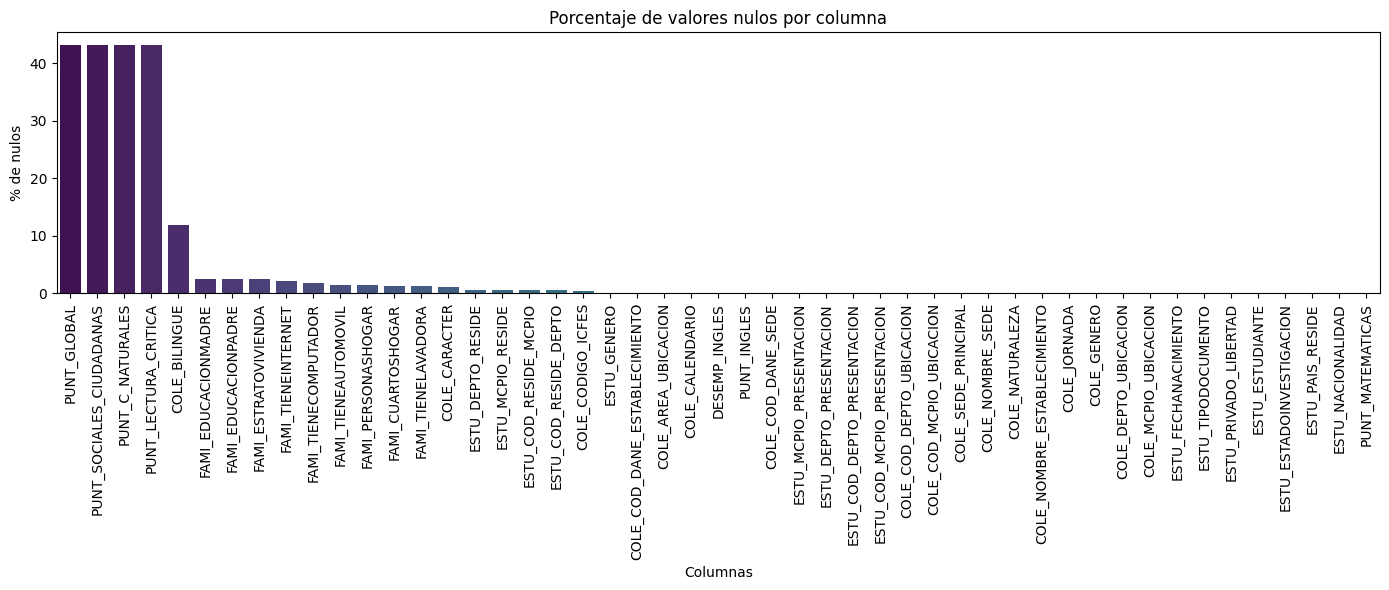

In [5]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DataFrame Spark
aux = datosIcfes

# Total de filas
total_rows = aux.count()

# Calcular porcentaje de nulos por columna
null_percent = aux.select([
    (
        F.count(F.when(F.col(c).isNull(), c)) / F.lit(total_rows) * 100
    ).alias(c)
    for c in aux.columns
])

# Convertir a pandas
null_pd = null_percent.toPandas().T.reset_index()
null_pd.columns = ['columna', 'porcentaje_nulos']

# Filtrar solo columnas con nulos
null_pd = null_pd[null_pd['porcentaje_nulos'] > 0]

# Ordenar de mayor a menor
null_pd = null_pd.sort_values(by='porcentaje_nulos', ascending=False)

# ===== Verificación específica para PUNT_GLOBAL =====
punt_global_null = null_pd[
    null_pd['columna'] == 'PUNT_GLOBAL'
]

if not punt_global_null.empty:
    porcentaje_pg = punt_global_null['porcentaje_nulos'].values[0]
    print(f"La columna PUNT_GLOBAL tiene {porcentaje_pg:.2f}% de valores nulos.")
else:
    print("La columna PUNT_GLOBAL no tiene valores nulos.")

# ===== Gráfica =====
if not null_pd.empty:
    plt.figure(figsize=(14,6))

    sns.barplot(
        data=null_pd,
        x='columna',
        y='porcentaje_nulos',
        palette='viridis'
    )

    plt.xticks(rotation=90)
    plt.title('Porcentaje de valores nulos por columna')
    plt.xlabel('Columnas')
    plt.ylabel('% de nulos')

    plt.tight_layout()
    plt.show()
else:
    print("No hay valores nulos en el DataFrame.")

In [6]:
# ===== Verificación específica para PUNT_GLOBAL =====

# Calcular porcentaje de nulos solo para PUNT_GLOBAL
punt_global_null = aux.select(
    (
        F.count(F.when(F.col("PUNT_GLOBAL").isNull(), True)) 
        / F.count(F.lit(1)) * 100
    ).alias("pct_nulos")
).collect()[0]["pct_nulos"]

print(f"PUNT_GLOBAL tiene {punt_global_null:.2f}% de valores nulos.")

PUNT_GLOBAL tiene 43.21% de valores nulos.


In [7]:
total_rows

5007462

-  Inicialmente, se eliminaran los puntajes en las distintas áreas del conocimiento, pues el puntaje global es combinación lineal de los puntajes individuales, incluir estas variables sería pasar la respuesta al modelo.

In [8]:
# Obtener columnas que empiezan por PUNT_ excepto PUNT_GLOBAL
cols_to_drop = [
    c for c in aux.columns
    if c.startswith("PUNT_") and c != "PUNT_GLOBAL"
]

# Eliminar columnas
datosIcfes = datosIcfes.drop(*cols_to_drop)

# Verificar
print("Columnas eliminadas:")
print(cols_to_drop)

Columnas eliminadas:
['PUNT_INGLES', 'PUNT_MATEMATICAS', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_C_NATURALES', 'PUNT_LECTURA_CRITICA']


- Además , dado que se tiene suficiente muestra, se eliminaran las filas con valores nulos, no se realiza imputación porque los registros con datos nulos (sin contar las columnas de puntaje) no tienen un gran porcentaje de nulidad (Sin contar PUNT_GLOBAL).

In [9]:
datosIcfes = datosIcfes.dropna()

## Verificación tras el tratamiento

In [10]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DataFrame Spark
aux = datosIcfes

# Total de filas
total_rows = aux.count()

# Calcular porcentaje de nulos por columna
null_percent = aux.select([
    (
        F.count(F.when(F.col(c).isNull(), c)) / F.lit(total_rows) * 100
    ).alias(c)
    for c in aux.columns
])

# Convertir a pandas
null_pd = null_percent.toPandas().T.reset_index()
null_pd.columns = ['columna', 'porcentaje_nulos']

# Filtrar solo columnas con nulos
null_pd = null_pd[null_pd['porcentaje_nulos'] > 0]

# Ordenar de mayor a menor
null_pd = null_pd.sort_values(by='porcentaje_nulos', ascending=False)

# ===== Verificación específica para PUNT_GLOBAL =====
punt_global_null = null_pd[
    null_pd['columna'] == 'PUNT_GLOBAL'
]

if not punt_global_null.empty:
    porcentaje_pg = punt_global_null['porcentaje_nulos'].values[0]
    print(f"La columna PUNT_GLOBAL tiene {porcentaje_pg:.2f}% de valores nulos.")
else:
    print("La columna PUNT_GLOBAL no tiene valores nulos.")

# ===== Gráfica =====
if not null_pd.empty:
    plt.figure(figsize=(14,6))

    sns.barplot(
        data=null_pd,
        x='columna',
        y='porcentaje_nulos',
        palette='viridis'
    )

    plt.xticks(rotation=90)
    plt.title('Porcentaje de valores nulos por columna')
    plt.xlabel('Columnas')
    plt.ylabel('% de nulos')

    plt.tight_layout()
    plt.show()
else:
    print("No hay valores nulos en el DataFrame.")

La columna PUNT_GLOBAL no tiene valores nulos.
No hay valores nulos en el DataFrame.


In [11]:
total_rows # Se tiene suficiente muestra para hacer el entrenamiento del modelo de aprendizaje de maquina

2331101

**Satisfactorio**

In [12]:
datosIcfes.columns

['PERIODO',
 'ESTU_TIPODOCUMENTO',
 'ESTU_CONSECUTIVO',
 'COLE_AREA_UBICACION',
 'COLE_BILINGUE',
 'COLE_CALENDARIO',
 'COLE_CARACTER',
 'COLE_COD_DANE_ESTABLECIMIENTO',
 'COLE_COD_DANE_SEDE',
 'COLE_COD_DEPTO_UBICACION',
 'COLE_COD_MCPIO_UBICACION',
 'COLE_CODIGO_ICFES',
 'COLE_DEPTO_UBICACION',
 'COLE_GENERO',
 'COLE_JORNADA',
 'COLE_MCPIO_UBICACION',
 'COLE_NATURALEZA',
 'COLE_NOMBRE_ESTABLECIMIENTO',
 'COLE_NOMBRE_SEDE',
 'COLE_SEDE_PRINCIPAL',
 'ESTU_COD_DEPTO_PRESENTACION',
 'ESTU_COD_MCPIO_PRESENTACION',
 'ESTU_COD_RESIDE_DEPTO',
 'ESTU_COD_RESIDE_MCPIO',
 'ESTU_DEPTO_PRESENTACION',
 'ESTU_DEPTO_RESIDE',
 'ESTU_ESTADOINVESTIGACION',
 'ESTU_ESTUDIANTE',
 'ESTU_FECHANACIMIENTO',
 'ESTU_GENERO',
 'ESTU_MCPIO_PRESENTACION',
 'ESTU_MCPIO_RESIDE',
 'ESTU_NACIONALIDAD',
 'ESTU_PAIS_RESIDE',
 'ESTU_PRIVADO_LIBERTAD',
 'FAMI_CUARTOSHOGAR',
 'FAMI_EDUCACIONMADRE',
 'FAMI_EDUCACIONPADRE',
 'FAMI_ESTRATOVIVIENDA',
 'FAMI_PERSONASHOGAR',
 'FAMI_TIENEAUTOMOVIL',
 'FAMI_TIENECOMPUTADOR',
 'FAM

- Se procede a eliminar las columnas que representan ID's o que representan información repetitiva, estas son aquellas que tienen "COD", pues sn codigos que representan un único valor en otra variable. Tambien se eliminan aquellas que presentan alta cardinalidad o alta variedad de valores posibles, pues pueden perjudicar el modelo.

In [13]:
# Columnas específicas a eliminar
cols_fijas = [
    'ESTU_TIPODOCUMENTO',
    'ESTU_CONSECUTIVO',
    'PERIODO'
    'ESTU_ESTUDIANTE', 
    'ESTU_ESTADOINVESTIGACION',
    'COLE_NOMBRE_ESTABLECIMIENTO', 'COLE_NOMBRE_SEDE', 'COLE_MCPIO_UBICACION', 'ESTU_MCPIO_PRESENTACION', 'ESTU_MCPIO_RESIDE', 'ESTU_DEPTO_PRESENTACION', 'ESTU_DEPTO_RESIDE','ESTU_FECHANACIMIENTO','PERIODO',
 'COLE_AREA_UBICACION',
 'COLE_BILINGUE',
 'COLE_CALENDARIO',
 'COLE_CARACTER',
 'COLE_DEPTO_UBICACION',
 'COLE_GENERO',
 'COLE_JORNADA',
 'COLE_NATURALEZA',
 'COLE_SEDE_PRINCIPAL',
 'ESTU_ESTUDIANTE'
]

# Columnas que contienen "COD"
cols_cod = [
    c for c in datosIcfes.columns
    if "COD" in c
]

# Unir todas las columnas a eliminar
cols_to_drop = cols_fijas + cols_cod

# Eliminar columnas
datosIcfes = datosIcfes.drop(*cols_to_drop)

# Verificación
print("Columnas eliminadas:")
print(cols_to_drop)

Columnas eliminadas:
['ESTU_TIPODOCUMENTO', 'ESTU_CONSECUTIVO', 'PERIODOESTU_ESTUDIANTE', 'ESTU_ESTADOINVESTIGACION', 'COLE_NOMBRE_ESTABLECIMIENTO', 'COLE_NOMBRE_SEDE', 'COLE_MCPIO_UBICACION', 'ESTU_MCPIO_PRESENTACION', 'ESTU_MCPIO_RESIDE', 'ESTU_DEPTO_PRESENTACION', 'ESTU_DEPTO_RESIDE', 'ESTU_FECHANACIMIENTO', 'PERIODO', 'COLE_AREA_UBICACION', 'COLE_BILINGUE', 'COLE_CALENDARIO', 'COLE_CARACTER', 'COLE_DEPTO_UBICACION', 'COLE_GENERO', 'COLE_JORNADA', 'COLE_NATURALEZA', 'COLE_SEDE_PRINCIPAL', 'ESTU_ESTUDIANTE', 'COLE_COD_DANE_ESTABLECIMIENTO', 'COLE_COD_DANE_SEDE', 'COLE_COD_DEPTO_UBICACION', 'COLE_COD_MCPIO_UBICACION', 'COLE_CODIGO_ICFES', 'ESTU_COD_DEPTO_PRESENTACION', 'ESTU_COD_MCPIO_PRESENTACION', 'ESTU_COD_RESIDE_DEPTO', 'ESTU_COD_RESIDE_MCPIO']


In [14]:
datosIcfes.columns

['ESTU_GENERO',
 'ESTU_NACIONALIDAD',
 'ESTU_PAIS_RESIDE',
 'ESTU_PRIVADO_LIBERTAD',
 'FAMI_CUARTOSHOGAR',
 'FAMI_EDUCACIONMADRE',
 'FAMI_EDUCACIONPADRE',
 'FAMI_ESTRATOVIVIENDA',
 'FAMI_PERSONASHOGAR',
 'FAMI_TIENEAUTOMOVIL',
 'FAMI_TIENECOMPUTADOR',
 'FAMI_TIENEINTERNET',
 'FAMI_TIENELAVADORA',
 'DESEMP_INGLES',
 'PUNT_GLOBAL']

In [15]:
datosIcfes.select("FAMI_ESTRATOVIVIENDA").distinct().show()
"""'FAMI_EDUCACIONMADRE',
 'FAMI_EDUCACIONPADRE',
 'FAMI_ESTRATOVIVIENDA'"""

+--------------------+
|FAMI_ESTRATOVIVIENDA|
+--------------------+
|           Estrato 3|
|           Estrato 2|
|           Estrato 6|
|           Estrato 4|
|         Sin Estrato|
|           Estrato 1|
|           Estrato 5|
+--------------------+



"'FAMI_EDUCACIONMADRE',\n 'FAMI_EDUCACIONPADRE',\n 'FAMI_ESTRATOVIVIENDA'"

**Satisfactorio**

In [16]:
"""## Conversion de tipos de datos adecuados
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType

# Numéricas
datosIcfes = datosIcfes \
    .withColumn("PUNT_GLOBAL", F.col("PUNT_GLOBAL").cast(DoubleType())) \
    .withColumn("FAMI_CUARTOSHOGAR", F.col("FAMI_CUARTOSHOGAR").cast(IntegerType())) \
    .withColumn("FAMI_PERSONASHOGAR", F.col("FAMI_PERSONASHOGAR").cast(IntegerType()))



# Booleanas (S/N -> True/False)
bool_cols = [
             "FAMI_TIENEAUTOMOVIL", "FAMI_TIENECOMPUTADOR",
             "FAMI_TIENEINTERNET", "FAMI_TIENELAVADORA"]

for col in bool_cols:
    datosIcfes = datosIcfes.withColumn(col, F.when(F.col(col) == "S", True)
                                .when(F.col(col) == "N", False)
                                .otherwise(None))"""

'## Conversion de tipos de datos adecuados\nfrom pyspark.sql import functions as F\nfrom pyspark.sql.types import IntegerType, DoubleType\n\n# Numéricas\ndatosIcfes = datosIcfes     .withColumn("PUNT_GLOBAL", F.col("PUNT_GLOBAL").cast(DoubleType()))     .withColumn("FAMI_CUARTOSHOGAR", F.col("FAMI_CUARTOSHOGAR").cast(IntegerType()))     .withColumn("FAMI_PERSONASHOGAR", F.col("FAMI_PERSONASHOGAR").cast(IntegerType()))\n\n\n\n# Booleanas (S/N -> True/False)\nbool_cols = [\n             "FAMI_TIENEAUTOMOVIL", "FAMI_TIENECOMPUTADOR",\n             "FAMI_TIENEINTERNET", "FAMI_TIENELAVADORA"]\n\nfor col in bool_cols:\n    datosIcfes = datosIcfes.withColumn(col, F.when(F.col(col) == "S", True)\n                                .when(F.col(col) == "N", False)\n                                .otherwise(None))'

**satisfactorio**

# Creación de un modelo de redes neuronales: Problema de regresión.
- Se abordará la pregunta: ¿Un estudiante superará el promedio nacional?, para ello se usara el clasificador perceptrónico multicapa de MLlib.

## Preprocesamiento necesario

In [17]:
datosIcfes.printSchema()

root
 |-- ESTU_GENERO: string (nullable = true)
 |-- ESTU_NACIONALIDAD: string (nullable = true)
 |-- ESTU_PAIS_RESIDE: string (nullable = true)
 |-- ESTU_PRIVADO_LIBERTAD: string (nullable = true)
 |-- FAMI_CUARTOSHOGAR: string (nullable = true)
 |-- FAMI_EDUCACIONMADRE: string (nullable = true)
 |-- FAMI_EDUCACIONPADRE: string (nullable = true)
 |-- FAMI_ESTRATOVIVIENDA: string (nullable = true)
 |-- FAMI_PERSONASHOGAR: string (nullable = true)
 |-- FAMI_TIENEAUTOMOVIL: string (nullable = true)
 |-- FAMI_TIENECOMPUTADOR: string (nullable = true)
 |-- FAMI_TIENEINTERNET: string (nullable = true)
 |-- FAMI_TIENELAVADORA: string (nullable = true)
 |-- DESEMP_INGLES: string (nullable = true)
 |-- PUNT_GLOBAL: integer (nullable = true)



Se crea un conjunto de datos auxiliar.

In [18]:

# ─────────────────────────────────────────────
# 0. IMPORTS
# ─────────────────────────────────────────────
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType, IntegerType

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
)
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)



TARGET_COL = "PUNT_GLOBAL"
LABEL_COL  = "supera_promedio"

df = datosIcfes.sample(fraction=0.09, seed=3)
df = df.dropna()
df = df.withColumn(TARGET_COL, F.col(TARGET_COL).cast(FloatType()))

print(f"Total filas: {df.count():,}")

Total filas: 209,881


 ## Se crea la columna del promedio global y se define el orden propio de las variables categoricas ordinales con el fin de representar correctamente el fenomeno, pues estas variab les tienen un orden puntual.

In [19]:


# ─────────────────────────────────────────────
# 3. PROMEDIO GLOBAL → ETIQUETA BINARIA
# ─────────────────────────────────────────────
promedio_global = df.select(F.mean(TARGET_COL)).collect()[0][0]
print(f"\nPromedio global de {TARGET_COL}: {promedio_global:.2f}")

df = df.withColumn(
    LABEL_COL,
    F.when(F.col(TARGET_COL) > promedio_global, 1)
     .otherwise(0)
     .cast(IntegerType()),
)

print("\nDistribución de clases:")
df.groupBy(LABEL_COL).count().orderBy(LABEL_COL).show()

# ─────────────────────────────────────────────
# 4. COLUMNAS
# ─────────────────────────────────────────────
ORDINAL_COLS = {
    "FAMI_EDUCACIONMADRE": [
        "Ninguno",
        "Primaria incompleta",
        "Primaria completa",
        "Secundaria (Bachillerato) incompleta",
        "Secundaria (Bachillerato) completa",
        "Técnica o tecnológica incompleta",
        "Técnica o tecnológica completa",
        "Educación profesional incompleta",
        "Educación profesional completa",
        "Postgrado",
        "No sabe",
        "No Aplica",
    ],
    "FAMI_EDUCACIONPADRE": [
        "Ninguno",
        "Primaria incompleta",
        "Primaria completa",
        "Secundaria (Bachillerato) incompleta",
        "Secundaria (Bachillerato) completa",
        "Técnica o tecnológica incompleta",
        "Técnica o tecnológica completa",
        "Educación profesional incompleta",
        "Educación profesional completa",
        "Postgrado",
        "No sabe",
        "No Aplica",
    ],
    "FAMI_ESTRATOVIVIENDA": [
        "Sin Estrato",
        "Estrato 1",
        "Estrato 2",
        "Estrato 3",
        "Estrato 4",
        "Estrato 5",
        "Estrato 6",
    ],
}

# Columnas excluidas: identificadores, alta cardinalidad, fechas crudas
COLS_EXCLUIR = {
    "ESTU_ESTUDIANTE",
    "ESTU_ESTADOINVESTIGACION",
    "COLE_NOMBRE_ESTABLECIMIENTO",
    "COLE_NOMBRE_SEDE",
    "COLE_MCPIO_UBICACION",
    "ESTU_MCPIO_PRESENTACION",
    "ESTU_MCPIO_RESIDE",
    "ESTU_DEPTO_PRESENTACION",
    "ESTU_DEPTO_RESIDE",
    "ESTU_PRIVADO_LIBERTAD",
    "ESTU_NACIONALIDAD",
    "ESTU_PAIS_RESIDE",
    "COLE_SEDE_PRINCIPAL",
    "COLE_BILINGUE",
    "ESTU_FECHANACIMIENTO",
}

excluded = set(ORDINAL_COLS.keys()) | {TARGET_COL, LABEL_COL} | COLS_EXCLUIR

# Nominales (string, fuera de las ordinales y excluidas)
nominal_cols = [
    c for c, dtype in df.dtypes
    if dtype == "string" and c not in excluded
]

# Numéricos — valores originales, sin tocar
numeric_cols = [
    c for c, dtype in df.dtypes
    if dtype in ("int", "bigint", "double", "float")
    and c not in excluded
]

# Booleanos → cast a int (0/1), única conversión de tipo necesaria
boolean_cols = [
    c for c, dtype in df.dtypes
    if dtype == "boolean" and c not in excluded
]
for bc in boolean_cols:
    df = df.withColumn(bc, F.col(bc).cast(IntegerType()))

all_numeric_cols = numeric_cols + boolean_cols

print("\nColumnas ordinales :", list(ORDINAL_COLS.keys()))
print("Columnas nominales :", nominal_cols)
print("Columnas numéricas :", all_numeric_cols)
print("Columnas excluidas :", sorted(COLS_EXCLUIR))
df = df.fillna(0, subset=all_numeric_cols)  # Por seguridad
print("\nfillna(0) aplicado a columnas numéricas (solo reemplaza nulos).")


Promedio global de PUNT_GLOBAL: 255.53

Distribución de clases:
+---------------+------+
|supera_promedio| count|
+---------------+------+
|              0|110752|
|              1| 99129|
+---------------+------+


Columnas ordinales : ['FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE', 'FAMI_ESTRATOVIVIENDA']
Columnas nominales : ['ESTU_GENERO', 'FAMI_CUARTOSHOGAR', 'FAMI_PERSONASHOGAR', 'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET', 'FAMI_TIENELAVADORA', 'DESEMP_INGLES']
Columnas numéricas : []
Columnas excluidas : ['COLE_BILINGUE', 'COLE_MCPIO_UBICACION', 'COLE_NOMBRE_ESTABLECIMIENTO', 'COLE_NOMBRE_SEDE', 'COLE_SEDE_PRINCIPAL', 'ESTU_DEPTO_PRESENTACION', 'ESTU_DEPTO_RESIDE', 'ESTU_ESTADOINVESTIGACION', 'ESTU_ESTUDIANTE', 'ESTU_FECHANACIMIENTO', 'ESTU_MCPIO_PRESENTACION', 'ESTU_MCPIO_RESIDE', 'ESTU_NACIONALIDAD', 'ESTU_PAIS_RESIDE', 'ESTU_PRIVADO_LIBERTAD']

fillna(0) aplicado a columnas numéricas (solo reemplaza nulos).


## Se realiza encoding, pipeline y Ensambador necesario para los modelos en spark.

In [20]:


# ─────────────────────────────────────────────
# 5. ENCODING ORDINAL
#    UDF que mapea cada categoría a su índice según el orden jerárquico
#    definido en ORDINAL_COLS. Valores desconocidos → -1.0
# ─────────────────────────────────────────────
ordinal_encoded_cols = []

for col_name, ordered_categories in ORDINAL_COLS.items():
    mapping        = {cat: float(idx) for idx, cat in enumerate(ordered_categories)}
    broadcast_map  = sparkSigma.sparkContext.broadcast(mapping)
    udf_name       = f"{col_name}_ord"

    @F.udf(FloatType())
    def ordinal_udf(value, m=broadcast_map):
        if value is None:
            return -1.0          # nulo → -1 (fuera del rango ordinal)
        return m.value.get(value, -1.0)   # desconocido → -1

    df = df.withColumn(udf_name, ordinal_udf(F.col(col_name)))
    ordinal_encoded_cols.append(udf_name)

# ─────────────────────────────────────────────
# 6. PIPELINE DE FEATURES
#    Nominales: StringIndexer → OneHotEncoder
#    Todo lo demás: Se hace uso VectorAssembler
# ─────────────────────────────────────────────
pipeline_stages = []

ohe_nominal = [f"{c}_ohe" for c in nominal_cols]

if nominal_cols:
    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in nominal_cols
    ]
    encoders = [
        OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe", dropLast=True)
        for c in nominal_cols
    ]
    pipeline_stages += indexers + encoders

# VectorAssembler: numéricos originales + ordinales + OHE nominales
assembler_inputs = all_numeric_cols + ordinal_encoded_cols + ohe_nominal

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features",
    handleInvalid="keep",   # nulos restantes → 0.0 (comportamiento nativo de MLlib)
)
pipeline_stages.append(assembler)


## particion del conjunto de datos y aplicacion de los pasos del pipeline.

In [21]:

# ─────────────────────────────────────────────
# 7PARTICION DEL CONJUNTO DE DATOS TRAIN / TEST
# ─────────────────────────────────────────────
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)
print(f"\nTrain: {train_df.count():,} | Test: {test_df.count():,}")

# ─────────────────────────────────────────────
# 8. FIT DEL PIPELINE
# ─────────────────────────────────────────────
feature_pipeline = Pipeline(stages=pipeline_stages)
feature_model    = feature_pipeline.fit(train_df)

train_featured = feature_model.transform(train_df)
test_featured  = feature_model.transform(test_df)





Train: 168,171 | Test: 41,710


## Definición del modelo, entrenamiento y validación de resultados.

In [ ]:
# ─────────────────────────────────────────────
# 9. definicion del clasificado 
# ─────────────────────────────────────────────
n_features = train_featured.select("features").first()["features"].size
N_CLASES   = 2
layers_mlp = [n_features, 128, 64, 32, N_CLASES]

print(f"\nNúmero de features de entrada: {n_features}")
print(f"Arquitectura MLP             : {layers_mlp}")

mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol=LABEL_COL,
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    layers=layers_mlp,
    blockSize=128,
    maxIter=100,
    tol=1e-6,
    stepSize=0.03,
    solver="l-bfgs",
    seed=42,
)

# ─────────────────────────────────────────────
# 10. ENTRENAMIENTO
# ─────────────────────────────────────────────
print("\nEntrenando MultilayerPerceptronClassifier...")
mlp_model = mlp.fit(train_featured)
print("Entrenamiento completado.")


# . PREDICCIÓN

train_preds = mlp_model.transform(train_featured)
test_preds  = mlp_model.transform(test_featured)

print("\nMuestra de predicciones (test):")
test_preds.select(TARGET_COL, LABEL_COL, "prediction", "probability") \
    .show(10, truncate=False)

# ─────────────────────────────────────────────
# EVALUACIÓN
# ─────────────────────────────────────────────
print("\n─── Métricas (TEST) ───")

binary_eval = BinaryClassificationEvaluator(
    labelCol=LABEL_COL, rawPredictionCol="rawPrediction"
)
multi_eval = MulticlassClassificationEvaluator(
    labelCol=LABEL_COL, predictionCol="prediction"
)

auc       = binary_eval.evaluate(test_preds, {binary_eval.metricName: "areaUnderROC"})
pr_auc    = binary_eval.evaluate(test_preds, {binary_eval.metricName: "areaUnderPR"})
accuracy  = multi_eval.evaluate(test_preds,  {multi_eval.metricName:  "accuracy"})
precision = multi_eval.evaluate(test_preds,  {multi_eval.metricName:  "weightedPrecision"})
recall    = multi_eval.evaluate(test_preds,  {multi_eval.metricName:  "weightedRecall"})
f1        = multi_eval.evaluate(test_preds,  {multi_eval.metricName:  "f1"})

print(f"  AUC-ROC            : {auc:.4f}")
print(f"  AUC-PR             : {pr_auc:.4f}")
print(f"  Accuracy           : {accuracy:.4f}")
print(f"  Precision (ponder.): {precision:.4f}")
print(f"  Recall    (ponder.): {recall:.4f}")
print(f"  F1        (ponder.): {f1:.4f}")



Número de features de entrada: 46
Arquitectura MLP             : [46, 128, 64, 32, 2]

Entrenando MultilayerPerceptronClassifier...
Entrenamiento completado.

Muestra de predicciones (test):
+-----------+---------------+----------+-----------------------------------------+
|PUNT_GLOBAL|supera_promedio|prediction|probability                              |
+-----------+---------------+----------+-----------------------------------------+
|189.0      |0              |1.0       |[0.384914785437277,0.615085214562723]    |
|323.0      |1              |1.0       |[0.013498405939757789,0.9865015940602421]|
|314.0      |1              |1.0       |[0.3199637681776087,0.6800362318223913]  |
|324.0      |1              |1.0       |[0.009390699280585413,0.9906093007194147]|
|272.0      |1              |0.0       |[0.5981886817060417,0.40181131829395844] |
|383.0      |1              |1.0       |[0.011020486209046259,0.9889795137909538]|
|220.0      |0              |0.0       |[0.9183605873622088,0

Se aclara que por cuestiones temporales, se optó por usar el 10% de la base de datos como fuente de entrenamiento del modelo.

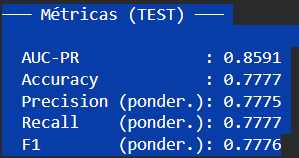

# Conclusiones
- Se logra predecir mejor que el azar si una persona superará el promedio nacional.
-  Spark es una herramienta clave para el tratamiento de altos volúmenes de datos, se intento hacer uso de pandas/sklearn pero fue imposible dado que en ese caso no se usa computación distribuida.
- Este modelo podría servir, por ejemplo, al Ministerio de educación que podría diseñar políticas públicas usando predicciones de grupos poblacionales.